# 3. Data Cleansing and Transformation

## 3.1 Data Cleaning and Preparation


In [2]:
import pandas as pd

df = pd.read_csv("../data/patient_data.csv")
df_original = df.copy(deep=True)

In [1]:
# Define the data cleaning function
def clean_data(data):
    clean = data.copy(deep=True)

    # Create the binary heart disease target from sublabel
    heart_disease_labels = ["HT", "DI_HT", "HT_HY", "DI_HT_HY"]
    clean["heart_disease_target"] = clean["sublabel"].isin(heart_disease_labels)

    # Remove duplicate rows
    clean = clean.drop_duplicates()

    # Reset the index after cleaning
    clean = clean.reset_index(drop=True)

    return clean

In [3]:
# Apply the cleaning function
df_clean = clean_data(df_original)

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df_original) - len(df_clean))

Original shape: (280985, 39)
Cleaned shape: (278701, 40)
Rows removed: 2284


In [4]:
print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nHeart disease target distribution:")
print(df_clean["heart_disease_target"].value_counts())

print("\nTarget mapping:")
print(
    pd.crosstab(
        df_clean["sublabel"],
        df_clean["heart_disease_target"]
    )
)


Duplicate rows:
0

Heart disease target distribution:
heart_disease_target
False    272810
True       5891
Name: count, dtype: int64

Target mapping:
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0


In [5]:
# Inspect disease related variables before deciding whether they should be retained
disease_related_columns = [
    "sublabel",
    "disease_flags",
    "label",
    "heart_disease",
    "diabetes",
    "hypertension"
]

for column in disease_related_columns:
    print(f"\n{column}")
    print(pd.crosstab(df_clean[column], df_clean["heart_disease_target"]))


sublabel
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0

disease_flags
heart_disease_target   False  True 
disease_flags                      
0,0,0                 104648      0
0,0,1                  69787      0
0,1,0                      0   2583
0,1,1                      0   1065
1,0,0                  31903      0
1,0,1                  66472      0
1,1,0                      0   1398
1,1,1                      0    845

label
heart_disease_target   False  True 
label                              
Abnormal              168162   5891
Normal                104648      0

heart_disease
heart_disease_target   False  True 
heart_disease                      
0.000000         

In [6]:
# Check the data types after cleaning
df_clean.dtypes

composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake             float64
heart_rate              float64
hdl     

In [8]:
# Check categorical values for formatting or inconsistent categories
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


composite_key
composite_key
Middle_Female_Overweight_Never_No      5600
Mature_Female_Overweight_Never_No      5415
Middle_Female_Obese_Never_No           5020
Mature_Female_Obese_Never_No           4986
Middle_Female_Normal_Never_No          4806
                                       ... 
Young_Female_Underweight_Current_No     184
Young_Female_Underweight_Never_Yes      176
Young_Male_Underweight_Former_Yes       175
Young_Male_Underweight_Current_Yes      161
Young_Female_Underweight_Former_Yes     147
Name: count, Length: 192, dtype: int64

age_level
age_level
Mature    87019
Middle    84478
Senior    69824
Young     37380
Name: count, dtype: int64

gender
gender
Female    147336
Male      131365
Name: count, dtype: int64

bmi_level
bmi_level
Obese          98377
Overweight     76897
Normal         70591
Underweight    32836
Name: count, dtype: int64

smoking
smoking
Never      125797
Former      80063
Current     72841
Name: count, dtype: int64

diabetes
diabetes
No     178083
Y

C:\Users\leoca\AppData\Local\Temp\ipykernel_2724\628714087.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include="object").columns


In [9]:
# Check numerical ranges after cleaning
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,278701.0,49.710381,21.682385,2.000000,32.000000,50.000000,68.000000,89.000000
age_normalized,278701.0,0.548395,0.249223,0.000000,0.344827,0.551724,0.758620,1.000000
bmi,278701.0,27.492328,7.068966,10.010000,22.010000,27.320000,32.700000,95.690000
hypertension,278701.0,0.129193,0.187602,0.000000,0.000000,0.071823,0.217063,1.000000
heart_disease,278701.0,0.073945,0.138504,0.000000,0.000000,0.007800,0.117647,1.000000
HbA1c_level,278701.0,5.951910,0.952495,3.500000,5.387500,5.800000,6.865766,9.000000
glucose,278701.0,135.267784,38.503495,70.000000,100.000000,137.000000,160.000000,300.000000
cholesterol,278701.0,224.027190,35.668600,150.000000,201.000000,225.000000,243.000000,300.000000
sleep_hours,278701.0,6.954743,1.432179,4.000000,6.196679,6.975185,7.700000,10.000000
triglycerides,278701.0,178.540442,67.344842,50.000000,128.000000,178.000000,241.750000,400.000000


In [10]:
# Inspect unusual age values
print(df_clean["age"].sort_values().head(20))

print("\nHighest BMI values:")
print(df_clean["bmi"].sort_values(ascending=False).head(20))

11860    2
11859    2
11858    2
46796    2
46795    2
46794    2
46793    2
46792    2
46791    2
46790    2
46789    2
46788    2
46787    2
46786    2
46785    2
46779    2
6916     2
6915     2
6909     2
6573     2
Name: age, dtype: int64

Highest BMI values:
54042    95.69
51824    95.22
53301    91.82
62841    88.76
69995    88.72
12015    87.70
57800    87.51
58143    83.74
46154    81.73
13786    79.48
13523    79.46
38519    75.78
25641    73.77
16583    72.89
58266    72.28
34899    72.21
91318    72.03
15193    71.55
15227    70.96
88503    69.66
Name: bmi, dtype: float64


In [11]:
# Inspect records with the minimum age
df_clean.loc[
    df_clean["age"] == df_clean["age"].min(),
    ["age", "age_level"]
].value_counts()

age  age_level
2    Young        1179
Name: count, dtype: int64

In [12]:
# Inspect the highest BMI records and their BMI categories
df_clean[
    ["bmi", "bmi_level"]
].sort_values(
    by="bmi",
    ascending=False
).head(20)

,bmi,bmi_level
54042,95.69,Obese
51824,95.22,Obese
53301,91.82,Obese
62841,88.76,Obese
69995,88.72,Obese
12015,87.70,Obese
57800,87.51,Obese
58143,83.74,Obese
46154,81.73,Obese
13786,79.48,Obese


## 3.2 Outlier Investigation and Treatment

In [19]:
# Define a function to flag potential outliers using the IQR method
def iqr_flag(series):
    # Calculate the first and third quartiles
    q1, q3 = series.quantile([0.25, 0.75])

    # Calculate the interquartile range
    iqr = q3 - q1

    # Flag values below or above the 1.5 × IQR boundaries
    return (
        (series < q1 - 1.5 * iqr)
        | (series > q3 + 1.5 * iqr)
    )

In [20]:
# Flag potential BMI outliers using the IQR method
bmi_flag = iqr_flag(df_clean["bmi"])

# Display the number of BMI values flagged as potential outliers
print("Number of BMI outliers:", bmi_flag.sum())

# Inspect the flagged records with relevant contextual variables
print(
    df_clean.loc[
        bmi_flag,
        ["age", "gender", "bmi", "bmi_level", "heart_disease_target"]
    ]
    .sort_values("bmi")
    .to_string()
)

Number of BMI outliers: 1005
       age  gender    bmi bmi_level  heart_disease_target
33499   50  Female  48.74     Obese                 False
58833   31  Female  48.75     Obese                 False
35926   22  Female  48.78     Obese                 False
92521   41    Male  48.78     Obese                 False
15865   38  Female  48.79     Obese                 False
7226    28  Female  48.80     Obese                 False
35155   54  Female  48.81     Obese                 False
92947   43    Male  48.81     Obese                 False
2941    29  Female  48.81     Obese                 False
89422   43    Male  48.82     Obese                 False
21250   47  Female  48.82     Obese                 False
80409   64    Male  48.82     Obese                  True
91397   42    Male  48.82     Obese                 False
76645   39    Male  48.82     Obese                 False
29886   56  Female  48.83     Obese                 False
10626   40  Female  48.83     Obese        

C:\Users\leoca\AppData\Local\Temp\ipykernel_2724\129251407.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


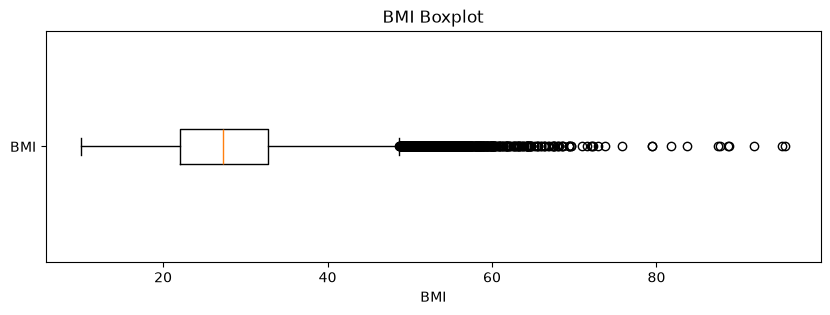

In [30]:
import matplotlib.pyplot as plt

# Create a boxplot to identify potential BMI outliers
plt.figure(figsize=(10, 3))

plt.boxplot(
    df_clean["bmi"].dropna(),
    vert=False,
    tick_labels=["BMI"]
)

plt.xlabel("BMI")
plt.title("BMI Boxplot")
plt.show()

In [ ]:
print("Number of BMI outliers:", bmi_flag.sum())
# Calculate the BMI IQR boundaries
q1 = df_clean["bmi"].quantile(0.25)
q3 = df_clean["bmi"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower boundary:", lower_bound)
print("Upper boundary:", upper_bound)

Q1: 22.01
Q3: 32.7
IQR: 10.690000000000001
Lower boundary: 5.974999999999998
Upper boundary: 48.73500000000001


C:\Users\leoca\AppData\Local\Temp\ipykernel_2724\4166637921.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


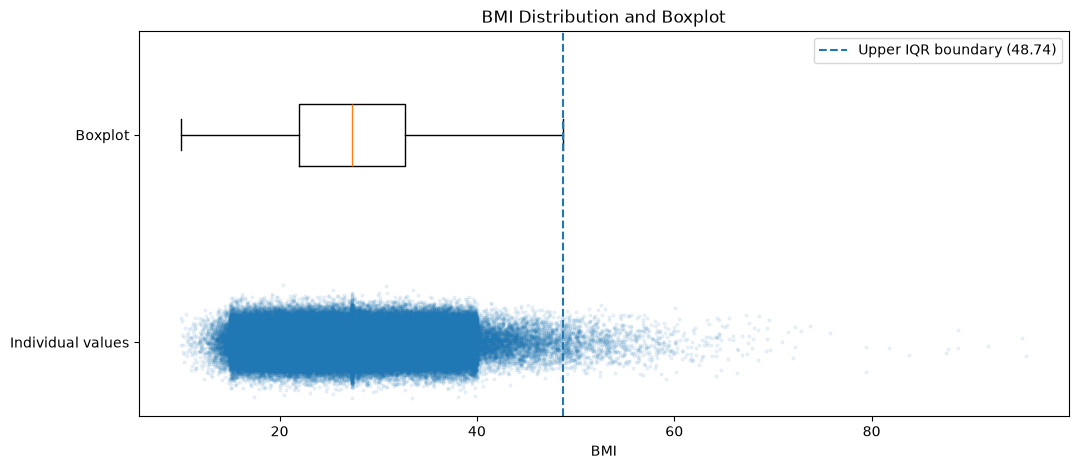

In [32]:
import numpy as np

# Set a random seed so the jitter is reproducible
np.random.seed(42)

# Create small vertical offsets for the individual observations
jitter = np.random.normal(
    loc=0,
    scale=0.06,
    size=len(df_clean)
)

# Create the figure
plt.figure(figsize=(12, 5))

# Plot all BMI observations with vertical jitter
plt.scatter(
    df_clean["bmi"],
    jitter,
    s=4,
    alpha=0.08
)

# Plot the boxplot above the individual observations
plt.boxplot(
    df_clean["bmi"].dropna(),
    vert=False,
    positions=[1],
    widths=0.3,
    showfliers=False
)

# Show the upper IQR boundary used for potential outlier detection
plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper IQR boundary ({upper_bound:.2f})"
)

# Label the graph
plt.yticks(
    [0, 1],
    ["Individual values", "Boxplot"]
)

plt.xlabel("BMI")
plt.title("BMI Distribution and Boxplot")
plt.legend()

plt.show()